# Haar cascade - Image Input

In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('/media/akashs/FA22E72622E6E69B/DATA1_disk/ACADEMICS/3_IPCS_Works/data/crowd_2.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


In [2]:
# Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


In [3]:
# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)


In [4]:
# Draw rectangles around detected faces
for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (255, 0, 0), 2)

# Convert image to RGB for matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


Total 13 nos of persons are detected!


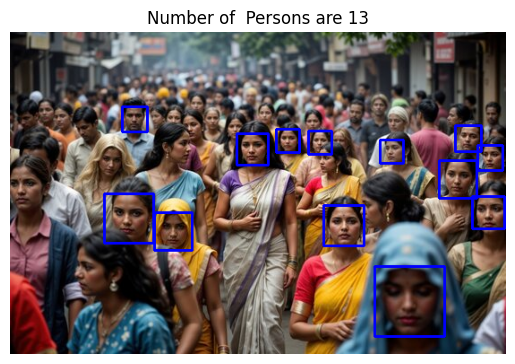

In [5]:
# Display the result
plt.imshow(image_rgb)
plt.axis('off')
# plt.title('Detected Face')
plt.title(f'Number of  Persons are {len(faces)}')
print(f"Total {len(faces)} nos of persons are detected!")
plt.show()

# YOLO - Image Input

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import time

In [2]:
# 🔹 Load pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")


0: 416x640 15 persons, 385.4ms
Speed: 6.3ms preprocess, 385.4ms inference, 3.4ms postprocess per image at shape (1, 3, 416, 640)
🟢 Detected: person: 0.87 at (310, 185, 405, 359)
🟢 Detected: person: 0.82 at (226, 99, 322, 359)
🟢 Detected: person: 0.78 at (0, 137, 86, 359)
🟢 Detected: person: 0.76 at (61, 220, 185, 359)
🟢 Detected: person: 0.72 at (156, 185, 247, 360)
🟢 Detected: person: 0.71 at (488, 165, 553, 359)
🟢 Detected: person: 0.71 at (361, 211, 521, 359)
🟢 Detected: person: 0.49 at (319, 124, 395, 258)
🟢 Detected: person: 0.44 at (112, 162, 216, 360)
🟢 Detected: person: 0.43 at (69, 114, 140, 225)
🟢 Detected: person: 0.41 at (138, 101, 220, 235)
🟢 Detected: person: 0.40 at (0, 264, 54, 359)
🟢 Detected: person: 0.39 at (445, 76, 495, 182)
🟢 Detected: person: 0.36 at (459, 134, 522, 247)
🟢 Detected: person: 0.27 at (112, 74, 162, 158)
 ------------------------------------------------------
Total 15 nos of persons are detected!
 ---------------------------------------------------

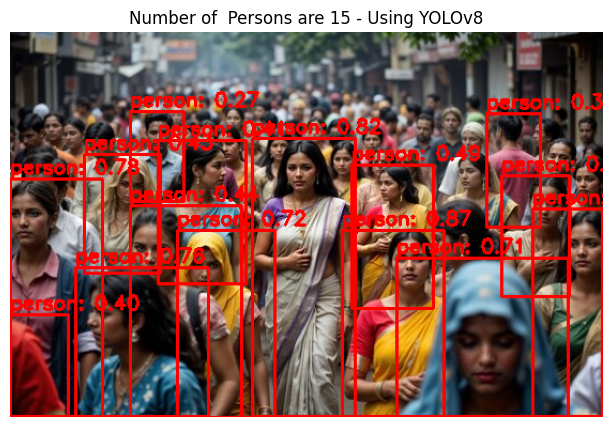

In [4]:
image_path = '/media/akashs/FA22E72622E6E69B/DATA1_disk/ACADEMICS/3_IPCS_Works/data/crowd_2.jpg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

results = model(img_rgb)

# 🔹 Extract results
boxes = results[0].boxes
names = model.names  # COCO class names


# Classes to detect: All animals (except birds) + all vehicles
allowed_labels = [
    'person']


for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    conf = box.conf[0].item()
    cls = int(box.cls[0].item())
    label_name = names[cls]
    label = f"{label_name}: {conf:.2f}"

    if label_name in allowed_labels:
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_rgb, label, (x1, y1 - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

        print(f"🟢 Detected: {label} at ({x1}, {y1}, {x2}, {y2})")


print(" ------------------------------------------------------")
print(f"Total {len(boxes)} nos of persons are detected!")
print(" ------------------------------------------------------")

# 🔹 Show final image
plt.figure(figsize=(10, 5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f'Number of  Persons are {len(boxes)} - Using YOLOv8')
plt.show()


# YOLO Video Input

In [5]:
%%time


# Access default webcam (0)
cap = cv2.VideoCapture("/media/akashs/FA22E72622E6E69B/DATA1_disk/ACADEMICS/3_IPCS_Works/data/yolo/traffic_2.mp4")

fourcc = cv2.VideoWriter_fourcc(*'XVID')
output_video_filename = f"./recordings/recorded_{time.strftime('%Y%m%d_%H%M%S')}.avi"
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_video_filename, fourcc, 20.0, (frame_width, frame_height))

img_counter = 0
print("Webcam started. Press 's' to save image, 'q' to quit.")
unique_ids = set()

while True:
    ret, frame = cap.read()
    if not ret:
        print("Webcam frame not received")
        break

    # -----------------------------
    # Draw Line, Rectangle, Circle, Text
    # -----------------------------
    height, width = frame.shape[:2]

    results = model(frame)

    # Extract results
    boxes = results[0].boxes
    names = model.names  # COCO class names

    # Classes to detect: All animals (except birds) + all vehicles
    allowed_labels = ['person']
    
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        cls = int(box.cls[0].item())
        label_name = names[cls]
        label = f"{label_name}: {conf:.2f}"
    
        if label_name in allowed_labels:
            cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    
            print(f"🟢 Detected: {label} at ({x1}, {y1}, {x2}, {y2})")
        
    
    results_track = model.track(frame, persist=True, conf=0.3)

    for box in results_track[0].boxes:
        cls = int(box.cls[0].item())
        label_name = model.names[cls]
    
        if label_name == 'person':
            track_id = int(box.id[0])  # ID assigned by tracker
            unique_ids.add(track_id)
    
    print(f"Total unique persons so far: {len(unique_ids)}")

    # -----------------------------
    # Save frame to video file
    # -----------------------------
    out.write(frame)

    # -----------------------------
    # Show webcam feed
    # -----------------------------
    cv2.imshow('Webcam Feed with Drawing', frame)

    # -----------------------------
    # Keypress handling
    # -----------------------------
    key = cv2.waitKey(1)
    if key & 0xFF == ord('q'):
        print("Exiting webcam...")
        break
    elif key & 0xFF == ord('s'):
        # Save snapshot image
        timestamp = time.strftime("%Y%m%d_%H%M%S")
        img_filename = f"snapshot_{timestamp}.jpg"
        cv2.imwrite(img_filename, frame)
        print(f"Snapshot saved: {img_filename}")
        img_counter += 1

# -----------------------------
# Release resources
# -----------------------------
cap.release()
out.release()
cv2.destroyAllWindows()
print(f"Recorded video saved as: {output_video_filename}")


Webcam started. Press 's' to save image, 'q' to quit.

0: 384x640 11 persons, 1 car, 6 motorcycles, 1 bus, 4 trucks, 242.7ms
Speed: 16.2ms preprocess, 242.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
🟢 Detected: person: 0.81 at (1394, 426, 1516, 659)
🟢 Detected: person: 0.77 at (852, 390, 1017, 740)
🟢 Detected: person: 0.76 at (103, 340, 289, 697)
🟢 Detected: person: 0.51 at (1591, 446, 1682, 629)
🟢 Detected: person: 0.47 at (1473, 437, 1568, 631)
🟢 Detected: person: 0.44 at (1770, 449, 1842, 613)
🟢 Detected: person: 0.43 at (1857, 452, 1919, 599)
🟢 Detected: person: 0.34 at (1669, 443, 1726, 599)
🟢 Detected: person: 0.33 at (1858, 454, 1918, 554)
🟢 Detected: person: 0.29 at (1710, 445, 1770, 590)
🟢 Detected: person: 0.26 at (40, 396, 84, 441)

0: 384x640 8 persons, 1 car, 2 motorcycles, 1 bus, 4 trucks, 177.1ms
Speed: 4.3ms preprocess, 177.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Total unique persons so far: 8

0: 384x640 7 persons, 